# Notebook 1 — Gamma Distribution: Mode=7 days, Median=45 days

Fit the gamma distribution and visualize why the mean is a poor summary statistic.

In [5]:
import sys
from pathlib import Path
import os

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import gamma as gamma_dist

# Resolve project root regardless of where Jupyter was launched.
# Works from: misc-jupyter-notebooks/, time_to_traffic_metric_design/, or notebooks/
_cwd = Path(os.getcwd())
_PROJECT_ROOT = next(
    (p.resolve() for p in [_cwd, _cwd.parent, _cwd / 'time_to_traffic_metric_design']
     if (p / 'time_to_traffic_sim').is_dir()),
    None,
)
if _PROJECT_ROOT is None:
    raise RuntimeError(
        f"Cannot locate time_to_traffic_sim from {_cwd}. "
        "Launch Jupyter from misc-jupyter-notebooks/ or time_to_traffic_metric_design/."
    )
sys.path.insert(0, str(_PROJECT_ROOT))
OUTPUT_DIR = _PROJECT_ROOT / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

from time_to_traffic_sim.gamma_params import fit_gamma_params, describe_distribution

In [6]:
import yaml
with open(_PROJECT_ROOT / 'config.yaml') as f:
    config = yaml.safe_load(f)

MODE_DAYS          = config['gamma']['mode_days']
MEDIAN_DAYS        = config['gamma']['median_days']
SEED               = config['simulation']['random_seed']
NEVER_TRAFFIC_FRAC = config['simulation']['never_traffic_fraction']
NEVER_TRAFFIC_DAYS = config['simulation']['never_traffic_days']

print(f'Config: mode={MODE_DAYS} d, median={MEDIAN_DAYS} d, '
      f'never-traffic={NEVER_TRAFFIC_FRAC:.0%} at {NEVER_TRAFFIC_DAYS:.0f} d, seed={SEED}')

Config: mode=7.0 d, median=45.0 d, never-traffic=1% at 400 d, seed=42


## Gamma Parameter Fitting

Solve numerically for the shape k and scale θ that simultaneously satisfy mode=`MODE_DAYS` and median=`MEDIAN_DAYS`. The solution uses a root-finder (`scipy.optimize.brentq`) since no closed-form exists.

In [7]:
k, theta = fit_gamma_params(mode_days=MODE_DAYS, median_days=MEDIAN_DAYS)
stats = describe_distribution(k, theta)

print(f'Gamma parameters:  shape k = {k:.4f},  scale θ = {theta:.4f}')
print()
for label, value in stats.items():
    print(f'  {label:>8s}: {value:7.2f} days')

Gamma parameters:  shape k = 1.1270,  scale θ = 55.1047

      mean:   62.10 days
       std:   58.50 days
      mode:    7.00 days
    median:   45.00 days
       p10:    8.06 days
       p25:   20.04 days
       p75:   85.95 days
       p90:  138.84 days
       p95:  178.40 days


## Distribution Shape (PDF)

Visualize the fitted PDF with mode, median, and mean marked. The right skew means the mean is pulled well above the median — a typical entity onboards much faster than the mean suggests.

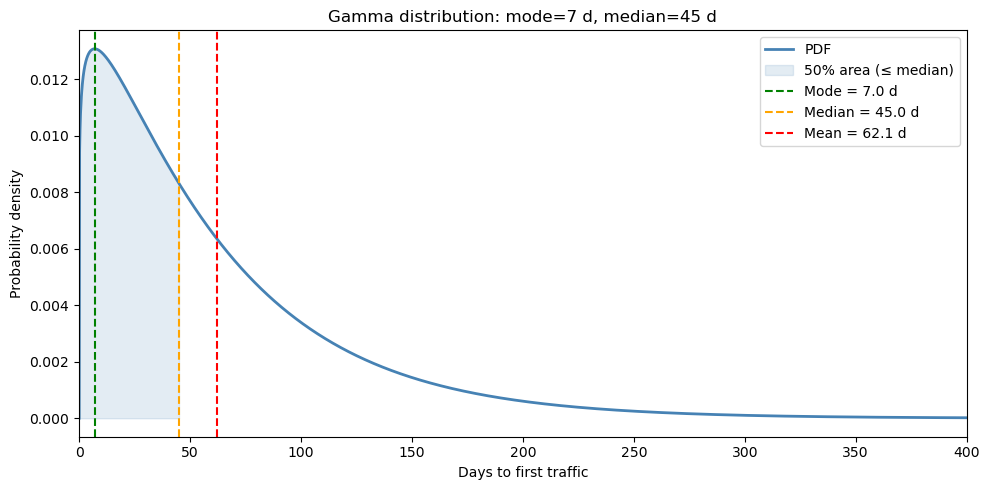


Note: mean (62.1 d) is 17.1 d above the median.
For right-skewed data the mean overstates typical entity experience.


In [8]:
x = np.linspace(0, 400, 2000)
pdf = gamma_dist.pdf(x, a=k, scale=theta)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, pdf, lw=2, color='steelblue', label='PDF')

# Fill area under the curve to median
x_fill = np.linspace(0, stats['median'], 500)
ax.fill_between(x_fill, gamma_dist.pdf(x_fill, a=k, scale=theta),
                alpha=0.15, color='steelblue', label='50% area (≤ median)')

ax.axvline(stats['mode'],   color='green',  lw=1.5, ls='--', label=f"Mode = {stats['mode']:.1f} d")
ax.axvline(stats['median'], color='orange', lw=1.5, ls='--', label=f"Median = {stats['median']:.1f} d")
ax.axvline(stats['mean'],   color='red',    lw=1.5, ls='--', label=f"Mean = {stats['mean']:.1f} d")

ax.set_xlabel('Days to first traffic')
ax.set_ylabel('Probability density')
ax.set_title('Gamma distribution: mode=7 d, median=45 d')
ax.legend()
ax.set_xlim(0, 400)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_gamma_pdf.png', dpi=150)
plt.show()
print(f"\nNote: mean ({stats['mean']:.1f} d) is {stats['mean'] - stats['median']:.1f} d above the median.")
print("For right-skewed data the mean overstates typical entity experience.")

## Cumulative Conversion Rates (CDF)

What fraction of entities have their first traffic event by day X? These checkpoints set expectations for onboarding timelines and help size observation windows.

In [9]:
# CDF — show what fraction of entities have first traffic by day 30, 60, 90
days_checkpoints = [7, 14, 30, 45, 60, 90, 120]
print('Cumulative fraction of entities with first traffic by day X:')
print(f'{"Day":>5}  {"CDF":>8}')
for d in days_checkpoints:
    print(f'{d:>5}  {gamma_dist.cdf(d, a=k, scale=theta):8.1%}')

Cumulative fraction of entities with first traffic by day X:
  Day       CDF
    7      8.6%
   14     17.6%
   30     36.0%
   45     50.0%
   60     61.1%
   90     76.7%
  120     86.1%


## Realistic assumption: never-traffic entities

A small fraction of entities (`NEVER_TRAFFIC_FRAC`, default 1%) never pass traffic within the
observation window. They are assigned a ceiling value of `NEVER_TRAFFIC_DAYS` (400 days).
This creates a **mixture distribution**:

- (1 − `NEVER_TRAFFIC_FRAC`) of entities: draw from Gamma(k, θ)
- `NEVER_TRAFFIC_FRAC` of entities: assigned exactly `NEVER_TRAFFIC_DAYS` (point mass)

The point mass at 400 days inflates both the population mean and the right tail, making the
mean a poor summary of typical onboarding speed. The **median** is far more robust.

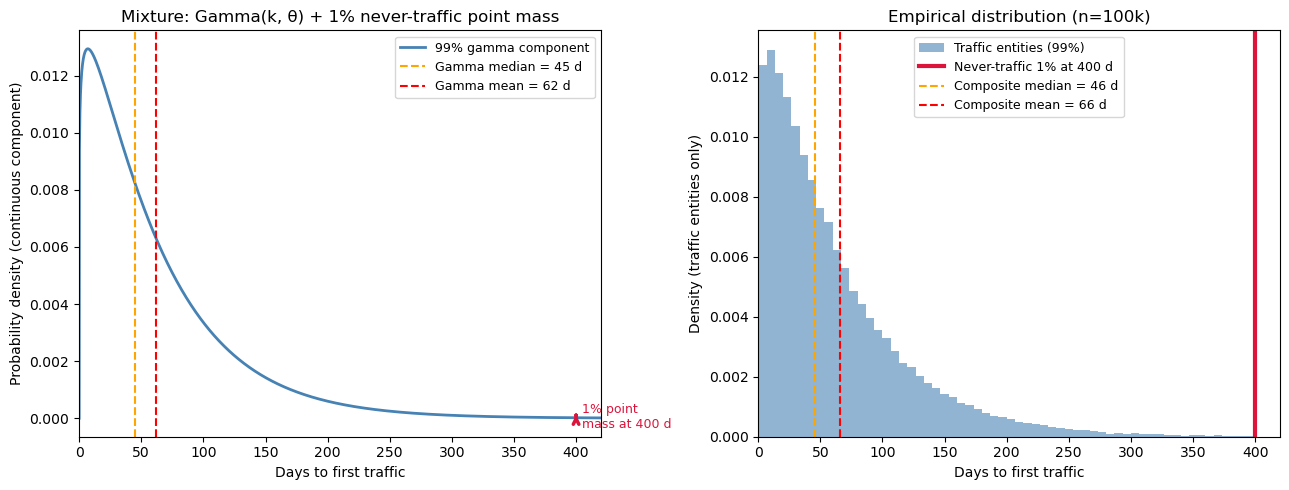

Gamma-only   — mean: 62.1 d,  median: 45.0 d
Composite    — mean: 65.8 d,  median: 45.6 d
Never-traffic entities add 3.7 d to the mean, 0.6 d to the median.


In [10]:
# Simulate a large sample to show the composite distribution
rng = np.random.default_rng(SEED)
n = 100_000
raw = rng.gamma(shape=k, scale=theta, size=n)
never_mask = rng.random(size=n) < NEVER_TRAFFIC_FRAC
composite = np.where(never_mask, NEVER_TRAFFIC_DAYS, raw)

composite_mean   = float(np.mean(composite))
composite_median = float(np.median(composite))

# Only the traffic (non-never) entities, clipped for histogram
traffic_days = composite[~never_mask]
bin_edges = np.linspace(0, 400, 61)  # explicit edges avoid numpy boundary bug

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: scaled PDF of gamma component + annotated point mass
ax = axes[0]
x = np.linspace(0, 420, 2000)
pdf_gamma = gamma_dist.pdf(x, a=k, scale=theta)
ax.plot(x, (1 - NEVER_TRAFFIC_FRAC) * pdf_gamma, lw=2, color='steelblue',
        label=f'{1 - NEVER_TRAFFIC_FRAC:.0%} gamma component')
ax.annotate('', xy=(NEVER_TRAFFIC_DAYS, NEVER_TRAFFIC_FRAC * 0.012),
            xytext=(NEVER_TRAFFIC_DAYS, 0),
            arrowprops=dict(arrowstyle='->', color='crimson', lw=2.5))
ax.text(NEVER_TRAFFIC_DAYS + 5, NEVER_TRAFFIC_FRAC * 0.006,
        f'{NEVER_TRAFFIC_FRAC:.0%} point\nmass at {NEVER_TRAFFIC_DAYS:.0f} d',
        color='crimson', fontsize=9, va='center')
ax.axvline(stats['median'], color='orange', lw=1.5, ls='--', label=f"Gamma median = {stats['median']:.0f} d")
ax.axvline(stats['mean'],   color='red',    lw=1.5, ls='--', label=f"Gamma mean = {stats['mean']:.0f} d")
ax.set_xlim(0, 420)
ax.set_xlabel('Days to first traffic')
ax.set_ylabel('Probability density (continuous component)')
ax.set_title(f'Mixture: Gamma(k, θ) + {NEVER_TRAFFIC_FRAC:.0%} never-traffic point mass')
ax.legend(fontsize=9)

# Right: histogram of traffic entities only; mark 400-day point mass separately
ax = axes[1]
ax.hist(traffic_days, bins=bin_edges, density=True,
        alpha=0.6, color='steelblue', label=f'Traffic entities ({1 - NEVER_TRAFFIC_FRAC:.0%})')
ax.axvline(NEVER_TRAFFIC_DAYS, color='crimson', lw=3,
           label=f'Never-traffic {NEVER_TRAFFIC_FRAC:.0%} at {NEVER_TRAFFIC_DAYS:.0f} d')
ax.axvline(composite_median, color='orange', lw=1.5, ls='--',
           label=f'Composite median = {composite_median:.0f} d')
ax.axvline(composite_mean,   color='red',    lw=1.5, ls='--',
           label=f'Composite mean = {composite_mean:.0f} d')
ax.set_xlim(0, 420)
ax.set_xlabel('Days to first traffic')
ax.set_ylabel('Density (traffic entities only)')
ax.set_title('Empirical distribution (n=100k)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_composite_distribution.png', dpi=150)
plt.show()

print(f'Gamma-only   — mean: {stats["mean"]:.1f} d,  median: {stats["median"]:.1f} d')
print(f'Composite    — mean: {composite_mean:.1f} d,  median: {composite_median:.1f} d')
print(f'Never-traffic entities add {composite_mean - stats["mean"]:.1f} d to the mean, '
      f'{composite_median - stats["median"]:.1f} d to the median.')

In [11]:
# ── Run simulation CLI or test suite from this notebook ──────────────────────
import subprocess

def run_simulation(config_path=None):
    """Run the full Monte Carlo simulation via bin/run_simulation.py."""
    cmd = [sys.executable, str(_PROJECT_ROOT / 'bin' / 'run_simulation.py'),
           '--config', str(config_path or _PROJECT_ROOT / 'config.yaml')]
    result = subprocess.run(cmd, capture_output=True, text=True, cwd=str(_PROJECT_ROOT))
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
    return result

def run_tests(verbose=True):
    """Run the project test suite with pytest."""
    cmd = [sys.executable, '-m', 'pytest', str(_PROJECT_ROOT / 'test')]
    if verbose:
        cmd.append('-v')
    result = subprocess.run(cmd, capture_output=True, text=True, cwd=str(_PROJECT_ROOT))
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
    return result

# Uncomment to run:
# run_simulation()
# run_tests()